# Can we distinguish two nominal populations in 8D state transition embeddings?

Both populations use the same checkpoint. Their `source_dataset` values identify
two independently generated batches, with different generation seeds. The question
is whether those populations differ in the saved IDK representation of [s, s']:

`[x1, x1', theta1, theta1', x2, x2', theta2, theta2']`

We compare HDBSCAN and spectral assignments with dataset membership, test population
differences with RBF-MMD and energy distance, and inspect UMAP/t-SNE colored by source.
All fitting and projection steps are unsupervised; source labels enter only the
subsequent comparisons. “Whole” means a whole prepared segment, which may cover only
part of its original episode.

Use the project's notebook environment (`python -m pip install -e ".[nb]"`).
Run from the repository root or a notebook subdirectory. 

In [1]:
import json
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances, silhouette_score
from umap import UMAP

from cartpole_idk.analytics.clustering import cluster_units
from cartpole_idk.analytics.evaluation import cluster_summary, evaluate_clusters
from cartpole_idk.analytics.metrics import pairwise
from cartpole_idk.analytics.population import population_mmd
from cartpole_idk.artifacts import EmbeddingArtifact
from cartpole_idk.model import ClusterConfig

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

ROOT = Path.cwd().resolve()
for _ in range(3):
    if not (ROOT / "pyproject.toml").exists():
        ROOT = ROOT.parent
    else:
        break
if not (ROOT / "pyproject.toml").exists():
    raise FileNotFoundError("Run from the repository root or notebooks directory.")

ARTIFACT_DIR = ROOT / (
    "artifacts/embeddings/200000-iter_nominal_500_episodes/"
    "psi-32_t-100_transition/200K-nom-v-nom-200ep/whole"
)
OUTPUT_DIR = ROOT / "artifacts/analysis/1-sanity-check/transition/nom-v-nom"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
MIN_CLUSTER_SIZE = 10
MIN_SAMPLES = 5
SPECTRAL_CLUSTERS = 2
UMAP_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
TSNE_PERPLEXITY = 30.0
N_PERMUTATIONS = 1999
MIXING_NEIGHBORS = 10

/Users/dma0523/code/research/cartpole-idk/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load the two source populations

`unit.record()` flattens provenance into columns, including `source_dataset` and
`source_trajectory_id`. Full dataset paths define membership; short labels are used
only for display. `source_return` describes the original rollout, while
`segment_return` and `raw_length` describe the prepared segment.

The distribution tests below use one segment per original trajectory. Repeated
segments from the same episode would require grouping permutations by episode.

In [2]:
artifact = EmbeddingArtifact.load(ARTIFACT_DIR)
embedded = artifact.embeddings
units = pd.DataFrame([unit.record() for unit in embedded.units])
assert artifact.config.unit.mode == "whole"
assert embedded.values.shape[0] == len(units)
if units[["source_dataset", "source_trajectory_id"]].isna().any().any():
    raise ValueError("Every unit needs source dataset and original trajectory provenance.")
if units.duplicated(["source_dataset", "source_trajectory_id"]).any():
    raise ValueError("Use one whole segment per original trajectory for these permutation tests.")

source_ids = sorted(units["source_dataset"].unique())
if len(source_ids) != 2 or units.groupby("source_dataset").size().min() < 2:
    raise ValueError("This notebook requires two source datasets with at least two trajectories each.")
source_names = {path: f"{letter}: {Path(path).name}" for letter, path in zip("AB", source_ids)}
source_colors = dict(zip(source_ids, ["#0072B2", "#D55E00"], strict=True))
source_codes = units["source_dataset"].map(dict(zip(source_ids, [0, 1], strict=True))).to_numpy()
group_a, group_b = [np.flatnonzero(source_codes == code) for code in (0, 1)]
units["source_label"] = units["source_dataset"].map(source_names)

print(f"{len(units)} units × {embedded.values.shape[1]} embedding features")
print(f"Representation: {artifact.config.fit.idk.representation}; psi={embedded.psi}; t={embedded.t}")
population_summary = units.groupby("source_dataset").agg(
    label=("source_label", "first"),
    units=("unit_id", "size"),
    source_trajectories=("source_trajectory_id", "nunique"),
    generation_seed=("generation_seed", "first"),
    mean_source_return=("source_return", "mean"),
    mean_segment_return=("segment_return", "mean"),
    min_segment_length=("raw_length", "min"),
    max_segment_length=("raw_length", "max"),
)
display(population_summary)

200 units × 3200 embedding features
Representation: transition; psi=32; t=100


,label,units,source_trajectories,generation_seed,mean_source_return,mean_segment_return,min_segment_length,max_segment_length
source_dataset,,,,,,,,
/Users/dma0523/code/research/cartpole-idk/datasets/generated/200000-iter_nominal/100_episodes,A: 100_episodes,100,100,20260921200000100,500.0,100.0,100,100
/Users/dma0523/code/research/cartpole-idk/datasets/generated/200000-iter_nominal/100_episodes_2,B: 100_episodes_2,100,100,7654321,500.0,100.0,100,100


## Cluster in the original embedding space

IDK distance is $\|\mu_i-\mu_j\|/\sqrt{t}$. `np.isfinite(distances).all()`
checks that **every distance is finite**: it rejects both infinities and NaNs.
Finite embedding vectors should yield finite distances. The symmetry check verifies
$d(i,j)=d(j,i)$; self-distances are zero.

HDBSCAN uses `min_cluster_size=10` and `min_samples=5`; label **-1** means noise.
Its membership strength describes association with the assigned cluster.
Spectral clustering explicitly requests **two clusters**, even if the populations
overlap. Neither algorithm receives source labels. Finding clusters does not by
itself establish that the two source populations differ.

In [3]:
distances = pairwise(embedded, metric="idk-distance")
affinity = pairwise(embedded, metric="idk")
# Reject NaN/inf values; all pairwise distances should be finite.
assert np.isfinite(distances).all(), "IDK distances contain NaN or infinity."
assert np.allclose(distances, distances.T), "IDK distances must be symmetric."
assert (distances >= 0).all(), "Distances must be nonnegative."
np.fill_diagonal(distances, 0.0)

hdbscan_config = ClusterConfig(
    algorithm="hdbscan",
    distance="idk-distance",
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
)
spectral_config = ClusterConfig(
    algorithm="spectral",
    n_clusters=SPECTRAL_CLUSTERS,
    random_state=SEED,
)
hdbscan_result = cluster_units(embedded, hdbscan_config, precomputed=distances)
spectral_result = cluster_units(embedded, spectral_config, precomputed=affinity)
results = {"HDBSCAN": hdbscan_result, "Spectral": spectral_result}

## Quantitative diagnostics: do clusters track source dataset?

**Cluster silhouette** uses the discovered cluster assignments and original IDK
distances. For each point, $a$ is its mean distance to other points in its cluster,
and $b$ is the smallest mean distance to another cluster. Its score is
$(b-a)/\max(a,b)$, averaged over points: near **1** means well separated clusters,
near **0** means overlap, and negative values mean points are closer on average to
another cluster. HDBSCAN noise is excluded; with fewer than two retained clusters,
the score is undefined. This describes cluster geometry, without using dataset labels.
See the [silhouette definition](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html).

**Source AMI** compares cluster assignments with `source_dataset`: approximately 0
is chance agreement and 1 is a perfect match. **Source purity** is the fraction in
each cluster's dominant dataset, averaged with cluster-size weights. Purity is not
chance-adjusted and can increase just by producing many small clusters.

Report scores both with noise excluded and with noise treated as an extra category.
The latter can reveal dataset-dependent rejection, but does not make noise a coherent
cluster. Composition tables and per-source noise rates show what the scores summarize.

In [4]:
metrics = []
cluster_counts = {}
coverage_tables = []
for name, result in results.items():
    report = evaluate_clusters(result.assignments, distances, categorical=("source_dataset",))
    all_report = evaluate_clusters(
        result.assignments, categorical=("source_dataset",), exclude_noise=False
    )
    metrics.append({
        "algorithm": name,
        "clusters": len(set(result.labels) - {-1}),
        "noise_units": report["n_noise"],
        "clustered_fraction": report["n_evaluated"] / len(units),
        "cluster_silhouette": report["silhouette"],
        "source_AMI_clustered": report["source_dataset"]["adjusted_mutual_information"],
        "source_purity_clustered": report["source_dataset"]["purity"],
        "source_AMI_including_noise": all_report["source_dataset"]["adjusted_mutual_information"],
    })
    cluster_counts[name] = pd.crosstab(
        result.labels, units["source_label"], rownames=["cluster"], colnames=["source_dataset"]
    )
    coverage = result.assignments.groupby("source_dataset").agg(
        units=("unit_id", "size"), noise_units=("is_noise", "sum"), noise_fraction=("is_noise", "mean")
    )
    coverage.insert(0, "algorithm", name)
    coverage_tables.append(coverage.reset_index())

metrics = pd.DataFrame(metrics).set_index("algorithm")
source_coverage = pd.concat(coverage_tables, ignore_index=True)
display(metrics.round(4))
display(source_coverage)
for name, counts in cluster_counts.items():
    print(f"{name}: counts by source dataset; -1 is noise")
    display(counts)
    print("Fraction from each dataset within each cluster:")
    display(counts.div(counts.sum(axis=1), axis=0).round(3))

hdbscan_summary, hdbscan_composition = cluster_summary(
    hdbscan_result.assignments, categorical=("source_dataset",)
)
strengths = hdbscan_result.assignments.groupby("cluster")["membership_strength"].mean()
hdbscan_summary = hdbscan_summary.join(strengths.rename("mean_membership_strength"), on="cluster")

,clusters,noise_units,clustered_fraction,cluster_silhouette,source_AMI_clustered,source_purity_clustered,source_AMI_including_noise
algorithm,,,,,,,
HDBSCAN,2,15,0.925,0.2878,0.0090,0.5405,0.0030
Spectral,2,0,1.000,0.3358,0.0089,0.5650,0.0089


,source_dataset,algorithm,units,noise_units,noise_fraction
0,/Users/dma0523/code/research/cartpole-idk/data...,HDBSCAN,100,8,0.08
1,/Users/dma0523/code/research/cartpole-idk/data...,HDBSCAN,100,7,0.07
2,/Users/dma0523/code/research/cartpole-idk/data...,Spectral,100,0,0.00
3,/Users/dma0523/code/research/cartpole-idk/data...,Spectral,100,0,0.00


HDBSCAN: counts by source dataset; -1 is noise


source_dataset,A: 100_episodes,B: 100_episodes_2
cluster,,
-1,8,7
0,78,86
1,14,7


Fraction from each dataset within each cluster:


source_dataset,A: 100_episodes,B: 100_episodes_2
cluster,,
-1,0.533,0.467
0,0.476,0.524
1,0.667,0.333


Spectral: counts by source dataset; -1 is noise


source_dataset,A: 100_episodes,B: 100_episodes_2
cluster,,
0,63,50
1,37,50


Fraction from each dataset within each cluster:


source_dataset,A: 100_episodes,B: 100_episodes_2
cluster,,
0,0.558,0.442
1,0.425,0.575


## Distribution differences without requiring separate clusters

Each trajectory embedding is one observation. Both tests compare the distributions
of these vectors in the shared fitted representation, using all trajectories including
HDBSCAN noise. Differences in the raw trajectories that this representation loses
cannot be detected here.

- **RBF-MMD squared** compares populations using a Gaussian kernel on their embedding
  vectors. We use the existing `population_mmd` implementation, an unbiased estimator,
  and the pooled median positive distance as bandwidth, fixed for every permutation.
  The estimate can be slightly negative from sampling variation; population MMD
  squared is nonnegative. See [Gretton et al.](https://www.jmlr.org/papers/v13/gretton12a.html).
- **Energy distance squared** uses $2\bar d_{AB}-\bar d_{AA}-\bar d_{BB}$ in IDK
  distance units, including self-pairs in the within-group means (the empirical
  V-statistic). It compares cross-population distances with within-population
  distances and needs no bandwidth. It has a positive finite-sample baseline under
  the null, so we calibrate it by shuffling labels. We explicitly use the squared
  convention described in the [energy distance documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.energy_distance.html),
  extended to Euclidean distances between vectors.

For each test, shuffle source labels **1,999 times**, preserving group sizes, and
report $(1 + \#\{T_{shuffle}\geq T_{observed}\})/(1+1999)$. This assumes independent,
exchangeable trajectories under the null and a fixed, shared representation.
Holm-adjusted p-values account for the two distribution tests. Small adjusted p-values
are evidence of a difference; large p-values do not establish equivalence. The
statistics have different scales and should not be compared numerically to each other.

In [5]:
mmd = population_mmd(
    embedded.subset(group_a.tolist()),
    embedded.subset(group_b.tolist()),
    estimator="unbiased",
    n_permutations=N_PERMUTATIONS,
    random_state=SEED,
)

def energy_squared(matrix, a, b):
    """Empirical energy distance squared, with within-group self-pairs included."""
    value = (
        2 * matrix[np.ix_(a, b)].mean()
        - matrix[np.ix_(a, a)].mean()
        - matrix[np.ix_(b, b)].mean()
    )
    return float(max(0.0, value))  # Clip floating-point roundoff at zero.

energy_observed = energy_squared(distances, group_a, group_b)
rng = np.random.default_rng(SEED)
energy_null = np.empty(N_PERMUTATIONS)
for i in range(N_PERMUTATIONS):
    order = rng.permutation(len(units))
    energy_null[i] = energy_squared(distances, order[:len(group_a)], order[len(group_a):])
energy_p = (1 + np.count_nonzero(energy_null >= energy_observed)) / (N_PERMUTATIONS + 1)

distribution_metrics = pd.DataFrame([
    {"metric": "RBF-MMD squared", "statistic": mmd.statistic, "p_value": mmd.p_value},
    {"metric": "Energy distance squared", "statistic": energy_observed, "p_value": energy_p},
]).set_index("metric")
# Holm correction across the two prespecified distribution tests.
p_values = distribution_metrics["p_value"].to_numpy()
p_order = np.argsort(p_values)
adjusted = np.empty_like(p_values)
adjusted[p_order] = np.minimum(1, np.maximum.accumulate(
    p_values[p_order] * np.arange(len(p_values), 0, -1)
))
distribution_metrics["p_value_holm"] = adjusted
distribution_metrics["n_a"] = len(group_a)
distribution_metrics["n_b"] = len(group_b)
distribution_metrics["permutations"] = N_PERMUTATIONS
display(distribution_metrics.round(6))
print(f"MMD bandwidth: {mmd.bandwidth:.4f} in raw embedding Euclidean units "
      f"({mmd.bandwidth / np.sqrt(embedded.t):.4f} in IDK distance units).")

,statistic,p_value,p_value_holm,n_a,n_b,permutations
metric,,,,,,
RBF-MMD squared,0.010167,0.0390,0.078,100,100,1999
Energy distance squared,0.008828,0.0405,0.078,100,100,1999


MMD bandwidth: 2.3206 in raw embedding Euclidean units (0.2321 in IDK distance units).


## Within-source and between-source distance distributions

Compare distinct pairs within A, distinct pairs within B, and all A–B pairs.
Similar curves suggest similar distance scales. Differences in spread can occur
even when population centroids are close. These pairs share trajectories and are
dependent: the pair counts below are descriptive, not independent sample sizes.
Inference above permutes the 200 trajectory labels, rather than individual distances.

,pair_count,mean,median,q10,q90
pairs,,,,,
Within A,4950,0.2416,0.2468,0.1130,0.3585
Within B,4950,0.2178,0.2144,0.0955,0.3437
Between A and B,10000,0.2318,0.2335,0.1037,0.3536


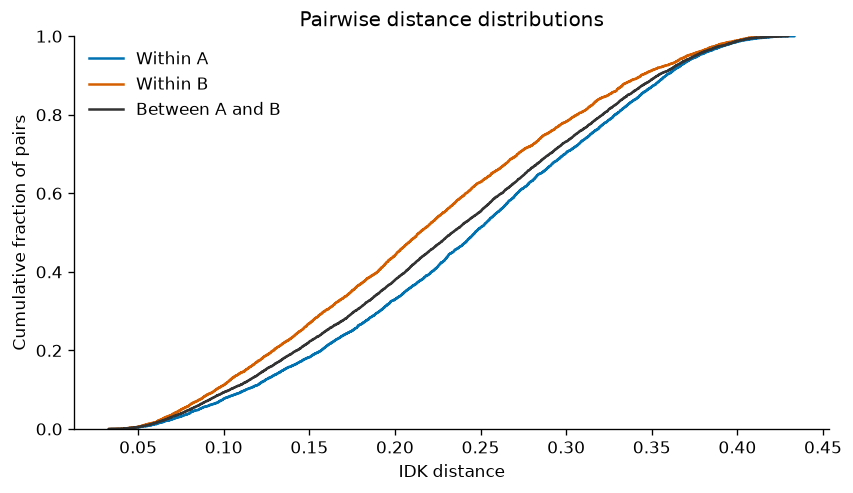

In [6]:
within_a = distances[np.ix_(group_a, group_a)][np.triu_indices(len(group_a), 1)]
within_b = distances[np.ix_(group_b, group_b)][np.triu_indices(len(group_b), 1)]
between = distances[np.ix_(group_a, group_b)].ravel()
pair_groups = {"Within A": within_a, "Within B": within_b, "Between A and B": between}
distance_summary = pd.DataFrame([
    {"pairs": name, "pair_count": len(values), "mean": values.mean(),
     "median": np.median(values), "q10": np.quantile(values, 0.1),
     "q90": np.quantile(values, 0.9)}
    for name, values in pair_groups.items()
]).set_index("pairs")
display(distance_summary.round(4))
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
for (name, values), color in zip(pair_groups.items(), ["#0072B2", "#D55E00", "#333333"], strict=True):
    ax.ecdf(values, label=name, color=color)
ax.set(xlabel="IDK distance", ylabel="Cumulative fraction of pairs", title="Pairwise distance distributions")
ax.legend(frameon=False)
fig.savefig(OUTPUT_DIR / "source_distance_distributions.png", dpi=180)
plt.show()

## UMAP and t-SNE: source populations and cluster assignments

Both projections receive the same precomputed IDK distances, without source labels.
The top row colors points by `source_dataset`; the other rows reuse the exact same
coordinates with HDBSCAN and spectral colors. This shows whether visible structures
align with source population or contain a mixture of both datasets.

Projection axes, cluster area, and spacing are exploratory. UMAP and t-SNE can
distort geometry and create apparent gaps; distribution tests above use the original
representation. See [UMAP's clustering guidance](https://umap-learn.readthedocs.io/en/latest/clustering.html).
t-SNE uses random initialization because PCA initialization is unavailable for
precomputed distances. Fixed seeds make these runs reproducible within an environment.

In [7]:
if not 2 <= UMAP_NEIGHBORS < len(units):
    raise ValueError("UMAP_NEIGHBORS must be between 2 and n_units - 1.")
if not 0 < TSNE_PERPLEXITY < len(units):
    raise ValueError("TSNE_PERPLEXITY must be positive and less than n_units.")

umap_coordinates = UMAP(
    n_components=2,
    metric="precomputed",
    n_neighbors=UMAP_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    random_state=SEED,
    n_jobs=1,
).fit_transform(distances.copy())
tsne_model = TSNE(
    n_components=2,
    metric="precomputed",
    init="random",
    perplexity=TSNE_PERPLEXITY,
    learning_rate="auto",
    max_iter=1500,
    random_state=SEED,
)
tsne_coordinates = tsne_model.fit_transform(distances.copy())
projections = {"UMAP": umap_coordinates, "t-SNE": tsne_coordinates}
print(f"Final t-SNE KL divergence: {tsne_model.kl_divergence_:.4f}")

/Users/dma0523/code/research/cartpole-idk/.venv/lib/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")


Final t-SNE KL divergence: 0.1768


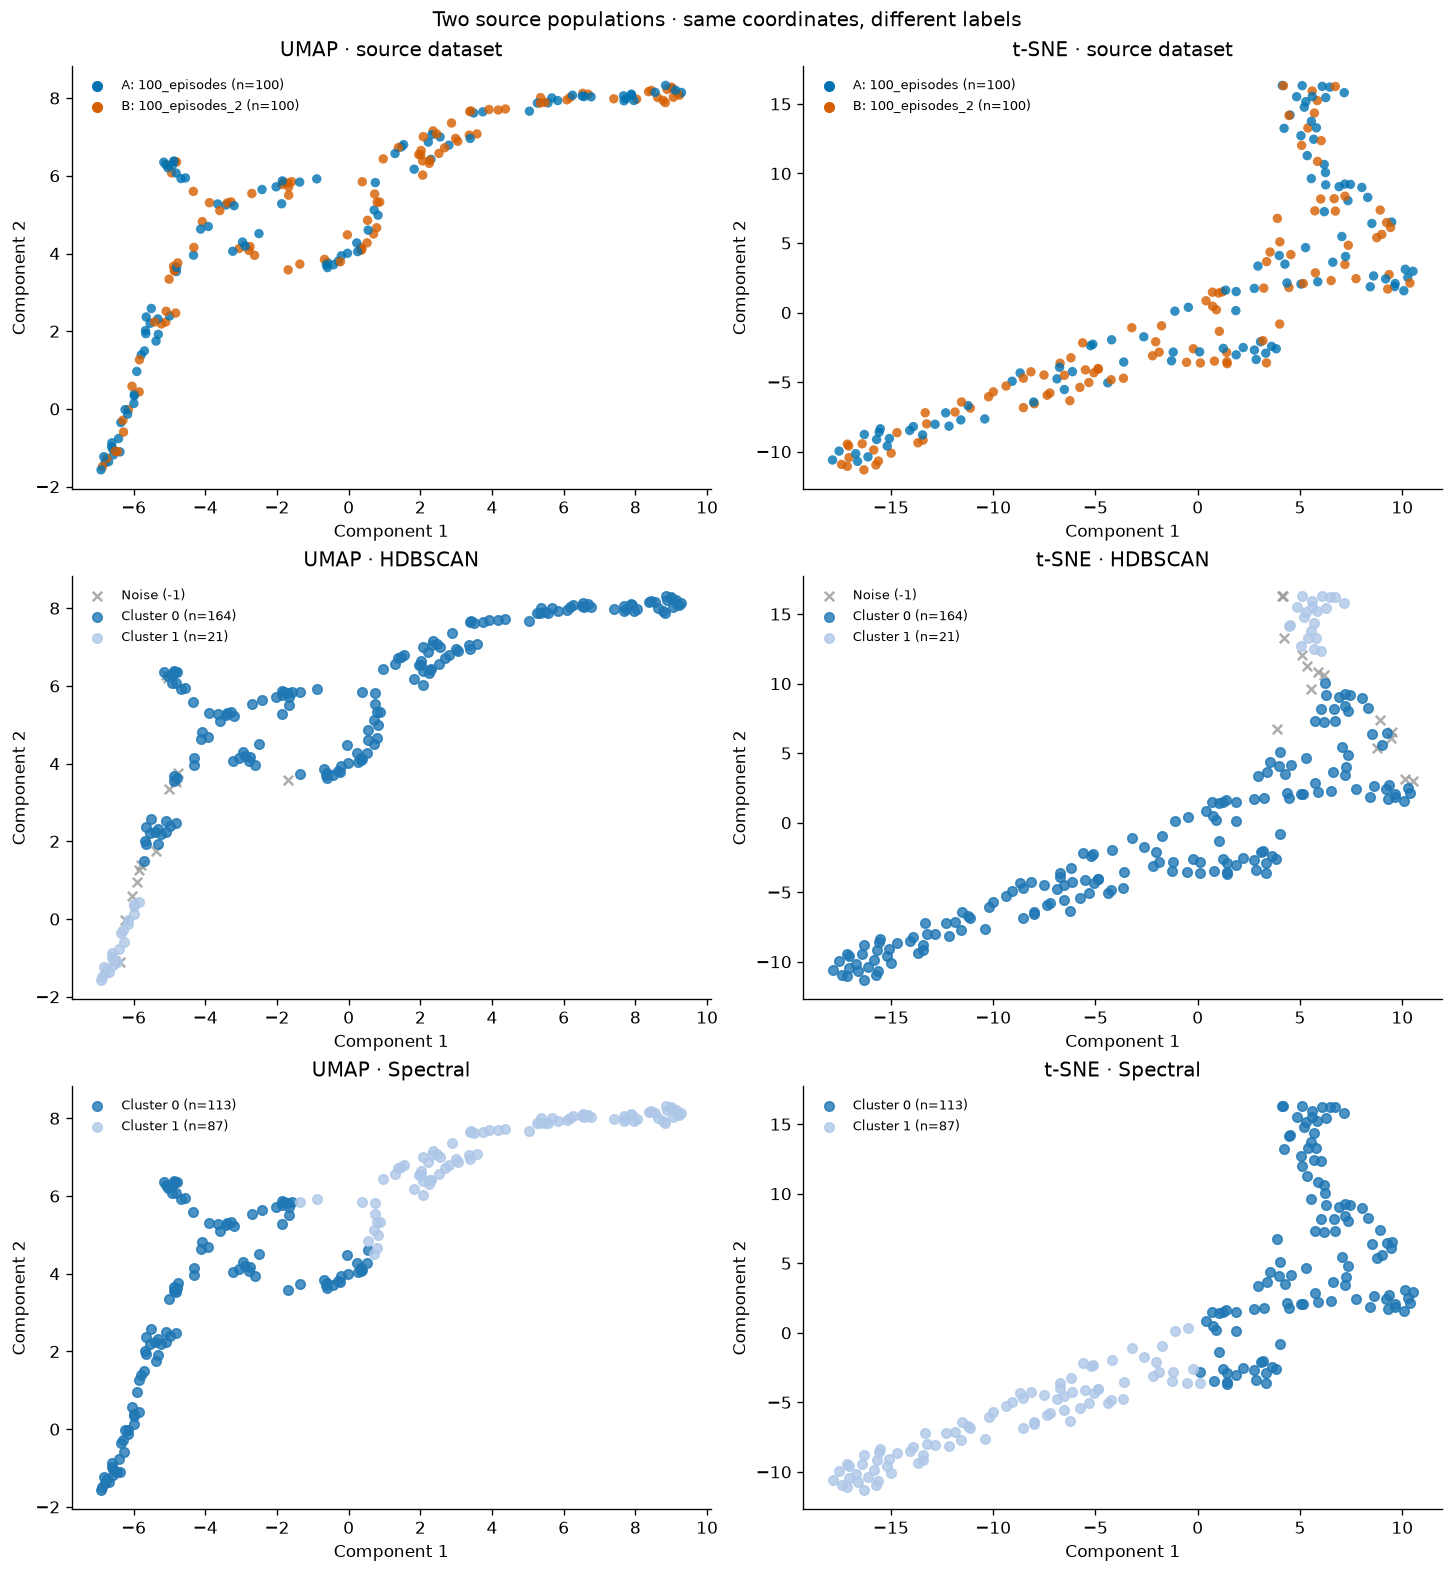

In [8]:
def plot_sources(ax, coordinates, frame, title, point_size=32, alpha=0.8):
    """Use full source paths for membership and short labels for the legend."""
    order = np.random.default_rng(SEED).permutation(len(frame))
    colors = frame["source_dataset"].map(source_colors).to_numpy()
    ax.scatter(coordinates[order, 0], coordinates[order, 1], c=colors[order],
               s=point_size, alpha=alpha, linewidths=0, rasterized=True)
    for source_id in source_ids:
        count = frame["source_dataset"].eq(source_id).sum()
        ax.scatter([], [], c=source_colors[source_id], s=32,
                   label=f"{source_names[source_id]} (n={count:,})")
    ax.set(title=title, xlabel="Component 1", ylabel="Component 2")
    ax.legend(fontsize=8, frameon=False)

def plot_clusters(ax, coordinates, labels, title):
    """Use consistent cluster colors and a separate gray marker for noise."""
    for label in sorted(np.unique(labels)):
        selected = labels == label
        ax.scatter(coordinates[selected, 0], coordinates[selected, 1],
                   c=["#999999" if label < 0 else plt.get_cmap("tab20")(int(label) % 20)],
                   marker="x" if label < 0 else "o", s=32, alpha=0.8,
                   label="Noise (-1)" if label < 0 else f"Cluster {label} (n={selected.sum()})")
    ax.set(title=title, xlabel="Component 1", ylabel="Component 2")
    ax.legend(fontsize=8, frameon=False)

fig, axes = plt.subplots(3, 2, figsize=(12, 13), constrained_layout=True)
for column, (name, coordinates) in enumerate(projections.items()):
    plot_sources(axes[0, column], coordinates, units, f"{name} · source dataset")
    plot_clusters(axes[1, column], coordinates, hdbscan_result.labels, f"{name} · HDBSCAN")
    plot_clusters(axes[2, column], coordinates, spectral_result.labels, f"{name} · Spectral")
fig.suptitle("Two source populations · same coordinates, different labels")
fig.savefig(OUTPUT_DIR / "source_dataset_umap_tsne.png", dpi=180)
plt.show()

## Source silhouette and local population mixing

**Source silhouette** uses the two `source_dataset` labels as the groups, includes
every trajectory, and asks whether those groups are geometrically separated. This
differs from cluster silhouette above, which uses algorithm assignments. Near zero
suggests overlap in this geometry; it does not rule out subtler distribution differences.

**Same-source neighbor fraction** measures the fraction of each point's ten nearest
neighbors drawn from its own dataset, averaged over all points, excluding itself.
Under shuffled labels, its expected value is approximately 0.5 for these balanced
populations (exactly 99/199 for 100 + 100). Larger values indicate local source
segregation. Ties are broken using a seeded, label-independent row shuffle.

The IDK row uses original distances. UMAP/t-SNE rows use Euclidean distances in the
displayed 2D coordinates and describe the projections only. These diagnostics are
exploratory; use the distribution tests for the two-sample inference.

In [9]:
if not 1 <= MIXING_NEIGHBORS < len(units):
    raise ValueError("MIXING_NEIGHBORS must be between 1 and n_units - 1.")
group_sizes = np.bincount(source_codes)
random_mixing = float(np.sum(group_sizes * (group_sizes - 1)) / (len(units) * (len(units) - 1)))
geometry_distances = {"Original IDK": distances}
geometry_distances.update({name: pairwise_distances(coords) for name, coords in projections.items()})
mixing_rows = []
tie_order = np.random.default_rng(SEED).permutation(len(units))
for name, matrix in geometry_distances.items():
    np.fill_diagonal(matrix, 0.0)
    ordered = tie_order[np.argsort(matrix[:, tie_order], axis=1, kind="stable")]
    # Remove each query's own index, including when multiple vectors coincide.
    neighbors = ordered[ordered != np.arange(len(units))[:, None]].reshape(len(units), -1)
    neighbors = neighbors[:, :MIXING_NEIGHBORS]
    mixing_rows.append({
        "geometry": name,
        "source_silhouette": silhouette_score(matrix, source_codes, metric="precomputed"),
        "same_source_neighbor_fraction": np.mean(source_codes[neighbors] == source_codes[:, None]),
        "random_label_expectation": random_mixing,
        "k": MIXING_NEIGHBORS,
    })
mixing_metrics = pd.DataFrame(mixing_rows).set_index("geometry")
display(mixing_metrics.round(4))

,source_silhouette,same_source_neighbor_fraction,random_label_expectation,k
geometry,,,,
Original IDK,0.0094,0.501,0.4975,10
UMAP,0.0143,0.506,0.4975,10
t-SNE,0.0137,0.498,0.4975,10


## Save comparisons, assignments, coordinates, and settings

Save full source dataset paths with every unit, both cluster assignments, membership
strengths, UMAP/t-SNE coordinates, cluster composition, distribution tests, and mixing
diagnostics. Settings record population labels, permutation count, bandwidth, seeds,
and package versions. Re-running replaces these notebook outputs.

The comparison concerns these two sampled populations in this fitted representation.
Overlap or nonsignificant tests do not prove that their underlying distributions are
identical. Different source generation seeds are provenance; they are not evidence
by themselves of a distribution shift.

In [10]:
assignments = units.copy()
assignments["hdbscan_cluster"] = hdbscan_result.labels
assignments["hdbscan_membership_strength"] = hdbscan_result.probabilities
assignments["spectral_cluster"] = spectral_result.labels
assignments[["umap_1", "umap_2"]] = umap_coordinates
assignments[["tsne_1", "tsne_2"]] = tsne_coordinates
assignments.to_parquet(OUTPUT_DIR / "assignments.parquet", index=False)
metrics.to_csv(OUTPUT_DIR / "metrics.csv")
population_summary.to_csv(OUTPUT_DIR / "population.csv")
source_coverage.to_csv(OUTPUT_DIR / "source_coverage.csv", index=False)
distribution_metrics.to_csv(OUTPUT_DIR / "distribution_metrics.csv")
distance_summary.to_csv(OUTPUT_DIR / "distance_summary.csv")
mixing_metrics.to_csv(OUTPUT_DIR / "source_mixing.csv")
np.save(OUTPUT_DIR / "energy_permutation_null.npy", energy_null)
for name, counts in cluster_counts.items():
    counts.to_csv(OUTPUT_DIR / f"{name.lower()}_source_counts.csv")
hdbscan_summary.to_csv(OUTPUT_DIR / "hdbscan_summary.csv", index=False)
hdbscan_composition.to_csv(OUTPUT_DIR / "hdbscan_composition.csv", index=False)

settings = {
    "artifact": str(ARTIFACT_DIR.relative_to(ROOT)),
    "artifact_id": artifact.metadata.artifact_id,
    "fit_id": embedded.basis_id,
    "seed": SEED,
    "population_field": "source_dataset",
    "source_labels": source_names,
    "source_colors": source_colors,
    "mixing_neighbors": MIXING_NEIGHBORS,
    "distribution_tests": {
        "permutations": N_PERMUTATIONS,
        "permutation_unit": "one whole segment per original trajectory",
        "p_value_adjustment": "Holm across RBF-MMD and energy tests",
        "mmd_estimator": mmd.estimator,
        "mmd_bandwidth_raw_embedding": mmd.bandwidth,
        "energy_estimator": "squared energy V-statistic in IDK distances",
    },
    "hdbscan": hdbscan_config.model_dump(mode="json"),
    "spectral": spectral_config.model_dump(mode="json"),
    "umap": {
        "metric": "precomputed",
        "n_neighbors": UMAP_NEIGHBORS,
        "min_dist": UMAP_MIN_DIST,
        "n_components": 2,
    },
    "tsne": {
        "metric": "precomputed",
        "perplexity": TSNE_PERPLEXITY,
        "init": "random",
        "learning_rate": "auto",
        "max_iter": 1500,
        "n_components": 2,
        "kl_divergence": float(tsne_model.kl_divergence_),
    },
    "versions": {
        name: version(name)
        for name in ["cartpole-idk", "numpy", "scipy", "pandas", "scikit-learn", "umap-learn", "matplotlib"]
    },
}
(OUTPUT_DIR / "settings.json").write_text(json.dumps(settings, indent=2) + "\n")
print(f"Saved results to {OUTPUT_DIR.relative_to(ROOT)}")

Saved results to artifacts/analysis/1-sanity-check/transition/nom-v-nom


---

## Optional: trajectory windows (25 steps), colored by source dataset

This section runs only if a compatible `window-25` artifact exists beside `whole`.
Each point represents a window and inherits its original trajectory's source dataset.
Both projections use the same population colors as the whole-trajectory plots.

Overlapping windows from one trajectory are dependent, and longer trajectories
contribute more points. Window plots are exploratory: no row-wise permutation tests
are performed here. The population table reports windows and original trajectories.

In [11]:
from sklearn.decomposition import TruncatedSVD

WINDOW_ARTIFACT_DIR = ARTIFACT_DIR.parent / "window-25"
WINDOW_OUTPUT_DIR = OUTPUT_DIR / "window-25"
RUN_WINDOWS = WINDOW_ARTIFACT_DIR.is_dir()
WINDOW_SVD_COMPONENTS = 50
WINDOW_UMAP_NEIGHBORS = 15
WINDOW_UMAP_MIN_DIST = 0.1
WINDOW_TSNE_PERPLEXITY = 30.0

if not RUN_WINDOWS:
    print(f"Skipping optional windows: no artifact at {WINDOW_ARTIFACT_DIR.relative_to(ROOT)}")
else:
    WINDOW_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    window_artifact = EmbeddingArtifact.load(WINDOW_ARTIFACT_DIR)
    artifact.compatible_with(window_artifact)
    window_embedded = window_artifact.embeddings
    window_units = pd.DataFrame([unit.record() for unit in window_embedded.units])
    assert window_artifact.config.unit.mode == "window"
    assert window_artifact.config.unit.window_length == 25
    assert window_units["raw_length"].eq(25).all()
    if window_units["source_dataset"].isna().any() or set(window_units["source_dataset"]) != set(source_ids):
        raise ValueError("Window artifact must contain the same two source datasets.")
    window_units["source_label"] = window_units["source_dataset"].map(source_names)
    window_population = window_units.groupby("source_dataset").agg(
        label=("source_label", "first"), windows=("unit_id", "size"),
        source_trajectories=("source_trajectory_id", "nunique"),
    )
    print(f"{len(window_units):,} windows × {window_embedded.values.shape[1]:,} embedding features")
    print(f"Window stride: {window_artifact.config.unit.stride} transition(s)")
    display(window_population)

Skipping optional windows: no artifact at artifacts/embeddings/200000-iter_nominal_500_episodes/psi-32_t-100_transition/200K-nom-v-nom-200ep/window-25


### Project the windows

Euclidean distance on `embedding / sqrt(t)` equals IDK distance. UMAP uses those
sparse features directly, avoiding a dense matrix of every window pair.
For t-SNE, reduce the sparse features to 50 SVD components and report the retained
variance. This approximates the original geometry. Source labels enter only coloring.

In [12]:
if RUN_WINDOWS:
    window_features = window_embedded.values / np.sqrt(window_embedded.t)
    window_svd = TruncatedSVD(n_components=WINDOW_SVD_COMPONENTS, random_state=SEED)
    window_reduced = window_svd.fit_transform(window_features)
    window_retained_variance = float(window_svd.explained_variance_ratio_.sum())
    print(
        f"t-SNE input: {WINDOW_SVD_COMPONENTS} SVD components retain "
        f"{window_retained_variance:.1%} of embedding variance"
    )

    window_umap_model = UMAP(
        n_components=2,
        metric="euclidean",
        n_neighbors=WINDOW_UMAP_NEIGHBORS,
        min_dist=WINDOW_UMAP_MIN_DIST,
        random_state=SEED,
        n_jobs=1,
    )
    window_umap_coordinates = window_umap_model.fit_transform(window_features)
    print("Window UMAP complete")

    window_tsne_model = TSNE(
        n_components=2,
        metric="euclidean",
        init="pca",
        perplexity=WINDOW_TSNE_PERPLEXITY,
        learning_rate="auto",
        max_iter=1500,
        random_state=SEED,
    )
    window_tsne_coordinates = window_tsne_model.fit_transform(window_reduced)
    print(f"Window t-SNE complete; final KL divergence: {window_tsne_model.kl_divergence_:.4f}")
    assert np.isfinite(window_umap_coordinates).all()
    assert np.isfinite(window_tsne_coordinates).all()

### Color windows by source dataset

Reuse the whole-trajectory dataset colors. Seeded shuffled drawing order avoids
systematically painting one population over the other. Apparent window-level density
also reflects how many windows each trajectory contributes.

In [13]:
if RUN_WINDOWS:
    window_projections = {"UMAP": window_umap_coordinates, "t-SNE": window_tsne_coordinates}
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
    for ax, (name, coordinates) in zip(axes, window_projections.items(), strict=True):
        plot_sources(ax, coordinates, window_units, f"{name} · source dataset", point_size=5, alpha=0.45)
    fig.suptitle("25-step windows · colored by source dataset")
    fig.savefig(WINDOW_OUTPUT_DIR / "source_dataset_umap_tsne.png", dpi=180)
    plt.show()

### Save window coordinates and source labels

Save the source dataset and trajectory IDs, window offsets, display labels, and both
projection coordinates. These outputs live in this comparison's `window-25` subdirectory.

In [14]:
if RUN_WINDOWS:
    window_points = window_units.copy()
    window_points[["umap_1", "umap_2"]] = window_umap_coordinates
    window_points[["tsne_1", "tsne_2"]] = window_tsne_coordinates
    window_points.to_parquet(WINDOW_OUTPUT_DIR / "points.parquet", index=False)
    window_population.to_csv(WINDOW_OUTPUT_DIR / "population.csv")
    window_settings = {
        "artifact": str(WINDOW_ARTIFACT_DIR.relative_to(ROOT)),
        "artifact_id": window_artifact.metadata.artifact_id,
        "fit_id": window_embedded.basis_id,
        "unit": window_artifact.config.unit.model_dump(mode="json"),
        "n_windows": len(window_units),
        "seed": SEED,
        "population_field": "source_dataset",
        "source_labels": source_names,
        "source_colors": source_colors,
        "feature_scaling": "embedding / sqrt(t)",
        "umap": {
            "n_components": 2,
            "metric": "euclidean",
            "n_neighbors": WINDOW_UMAP_NEIGHBORS,
            "min_dist": WINDOW_UMAP_MIN_DIST,
            "n_jobs": 1,
        },
        "tsne": {
            "n_components": 2,
            "metric": "euclidean",
            "init": "pca",
            "perplexity": WINDOW_TSNE_PERPLEXITY,
            "learning_rate": "auto",
            "max_iter": 1500,
            "svd_components": WINDOW_SVD_COMPONENTS,
            "svd_retained_variance": window_retained_variance,
            "kl_divergence": float(window_tsne_model.kl_divergence_),
        },
        "versions": settings["versions"],
    }
    (WINDOW_OUTPUT_DIR / "settings.json").write_text(json.dumps(window_settings, indent=2) + "\n")
    print(f"Saved window results to {WINDOW_OUTPUT_DIR.relative_to(ROOT)}")